In [1]:
import sys
sys.version

'3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:38:13) [GCC 12.3.0]'

# Function Definitions

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cripser
import persim
import re
import topapprox as ta
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import torch
import torch.optim as optim
from torch_topological.nn import CubicalComplex
import gudhi as gd

#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = 'cpu'
print('Device', device)

def band_PH(PH, lower=0, upper=np.inf):
  pers = np.diff(PH).reshape(-1)
  mask = (lower <= pers) & (pers < upper)
  return(PH[mask])

def pers_loss(D1,D2,pow=2,remove_longest_D1=True,remove_longest_D2=False):
  # D1,D2: persistence diagram of the shape [N,2]
  pers1 = torch.diff(D1).reshape(-1)
  #pers1 = pers1[torch.isfinite(pers1)]
  pers1,_ = torch.sort(pers1,dim=0)
  if remove_longest_D1:
    pers1 = pers1[:-1]
  pers2 = torch.diff(D2).reshape(-1)
  pers2,_ = torch.sort(pers2,dim=0)
  if remove_longest_D2:
    pers2 = pers2[:-1]
  #print(pers1,pers2)
  if len(pers1) > len(pers2):
    p = len(pers1)-len(pers2)
    loss = (pers1[:p]).pow(pow).sum()
    if len(pers2)>0:
      #loss += torch.nn.functional.l1_loss(pers1[p:],pers2)
      loss += (pers1[p:]-pers2).abs().pow(pow).sum()
    return(loss)
  else:
    p = len(pers2)-len(pers1)
    loss = (pers2[:p]).sum()
    if len(pers1)>0:
      loss += (pers2[p:]-pers2).abs().pow(pow).sum()
    return(loss)



Device cpu


In [48]:
def pers_band_filter(arr, eps0, eps1):
    ''' Filter all persistence intervals with persistence outside the interval
    [eps0, eps1]
    '''
    tfi = ta.TopologicalFilterImage(arr)
    return _pers_band_filter(tfi, eps0, eps1, keep_basin=True)

def _pers_band_filter(tfi, eps0, eps1, *, keep_basin=False):
    f0 = tfi.low_pers_filter(eps0, keep_basin=keep_basin)
    f1 = tfi.low_pers_filter(eps1)
    return (f0 - f1)

def pers_band_decompose(arr, eps_list:list):
    ''' Decompose `arr` into a list `arr_bands`
    in which `arr_bands[i] = pers_band_filter(arr, eps_list[i], eps_list[i+1])`
    for `i in range(n)`, with `n = len(eps_list)`, and set `arr[n+1]` as the
    `low_pers_filter` of `arr` with threshold `eps`
    In this way we have:
                arr = arr_bands[0] + arr_bands[1] + ... + arr_bands[n+1]
    '''
    eps_list.sort()
    if eps_list[0] <= 0:
        raise Exception("All threshold values in `eps_list` should be greater than 0")
    if eps_list[0] != 0:
        eps_list = [0] + eps_list

    tfi = ta.TopologicalFilterImage(arr)
    arr_low = [tfi.low_pers_filter(eps_list[0], keep_basin=True)]
    max_pers = np.max(tfi.persistence[1:,1] - tfi.persistence[1:,0]) # maximum finite persistence
    eps_list = [eps_list[0]] + [eps_list[i+1] for i in range(len(eps_list) - 1) if eps_list[i] < max_pers] # eliminate irrelevante thresholds
    arr_low += [tfi.low_pers_filter(eps_list[i]) for i in range(1, len(eps_list))]
    arr_bands = [arr_low[i] - arr_low[i+1] for i in range(0, len(eps_list)-1)] + [arr_low[-1]]
    return arr_bands

def shekel(shek,resolution=1000):
  x = np.linspace(0,999,resolution)
  arr = np.zeros(resolution)
  for i in range(len(shek)):
      arr += - 1 / ((1/shek[i][2])*0.001*(x - shek[i][0])**2 + (1/shek[i][1]))
  arr += abs(np.min(arr))
  return(x,arr)


# following are modification of https://github.com/ismav/sparseNMF/blob/master/sparse_nmf.py
def project_to_target_sparsity(vv, target_sparsity):
    v = vv.to('cpu').detach().numpy().copy()
    n = len(v)
    target = np.sqrt(n) - target_sparsity * (np.sqrt(n)-1)
    sumb = np.cumsum(v)
    normb = np.cumsum(v * v)
    pnormb = np.arange(1, n + 1) * normb
    y = (pnormb - sumb * sumb) / (np.arange(1, n + 1) - target * target)
    bot = int(np.ceil(target * target))
    z = np.zeros(n)
    obj = (-np.sqrt(y) * (np.arange(1, n + 1) + target) + sumb) / np.arange(1, n + 1)
    indx = np.argmax(obj[bot:n])
    p = indx + bot - 1
    p = min(p, n - 1)
    p = max(p, bot)
    lam = np.sqrt(y[p])
    mue = -sumb[p] / (p + 1) + target / (p + 1) * lam
    z[:p + 1] = (v[:p + 1] + mue) / lam
    return z

def update_W(X, W, H, k):
    HHt = H @ H.T
    cach = -X @ H.T + W @ HHt
    for i in range(W.shape[1]):
        C = cach[:, i] - W[:, i] * HHt[i, i]
        C = C.to('cpu').detach().numpy()
        wi = np.zeros(len(W))
        a = sparse_opt(np.sort(-C)[::-1], k)
        ind = np.argsort(-C)[::-1]
        wi[ind] = a
        wi = torch.as_tensor(wi)
        cach = cach + torch.outer(wi - W[:, i], HHt[i, :])
        W[:, i] = torch.as_tensor(wi)
    return W
    
def sparse_opt(b, k):
    n = len(b)
    sumb = np.cumsum(b)
    normb = np.cumsum(b * b)
    pnormb = np.arange(1, n + 1) * normb
    y = (pnormb - sumb * sumb) / (np.arange(1, n + 1) - k * k)
    bot = np.int64(np.ceil(k * k))
    z = np.zeros(n)
    if bot > n:
        print('Looks like the sparsity measure is not between 0 and 1\n')
        return
    obj = (-np.sqrt(y) * (np.arange(1, n + 1) + k) + sumb) / np.arange(1, n + 1)
    indx = np.argmax(obj[bot:n])
    p = indx + bot - 1
    p = min(p, n - 1)
    p = max(p, bot)
    lam = np.sqrt(y[p])
    mue = -sumb[p] / (p + 1) + k / (p + 1) * lam
    z[:p + 1] = (b[:p + 1] + mue) / lam
    return z

def sparsity_score(v):
    n = len(v.ravel())
    return((np.sqrt(n)-v.abs().sum()/(v**2).sum().sqrt())/(np.sqrt(n)-1))


# Band Filter

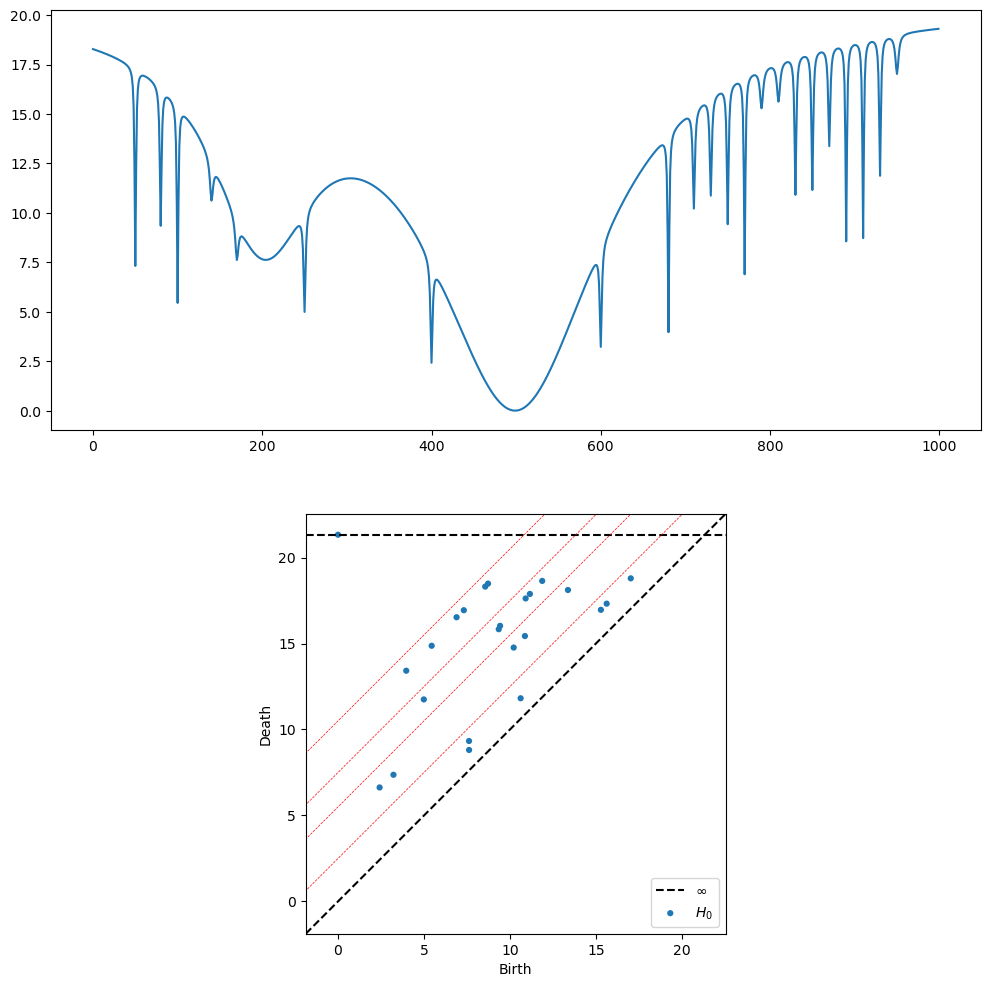

In [4]:
# each tupe in shek has three values (position, intesity, spread)
# position determines the position of the peak/valley in the x-axis
# intensity determines how strong the peak is (higher value = stronger)
# spread determines how spread the peak is (higher value = more spread)
shek = [(500, 20, 300),
        #(200, 15, 50),
        (200, 10, 50),
        (600, 5, 1e-2),
        (250, 5, 1e-2),
        (170, 2, 1e-2),
        (140, 2, 1e-2),
        (50, 10, 1e-2),
        (80, 7, 1e-2),
        (100, 10, 1e-2),
        (950, 2, 1e-2),
        (930, 7, 1e-2),
        (910, 10, 1e-2),
        (890, 10, 1e-2),
        (870, 5, 1e-2),
        (850, 7, 1e-2),
        (830, 7, 1e-2),
        (810, 2, 1e-2),
        (790, 2, 1e-2),
        (770, 10, 1e-2),
        (750, 7, 1e-2),
        (730, 5, 1e-2),
        (710, 5, 1e-2),
        (680, 10, 1e-2),
        (400, 5, 1e-2)]



x,arr = shekel(shek,resolution=1000)

fig, ax = plt.subplots(2, 1, figsize = (12, 12))
ax[0].plot(arr)

pd = cripser.computePH(arr,maxdim=2)
pd = [pd[pd[:,0]==i,1:3] for i in range(1)]
persim.plot_diagrams(pd, ax=ax[1])

eps_list = [2.5, 5.5, 7.5, 10.5]
for eps in eps_list:
    ax[1].plot([-100,100], [-100+eps,100+eps], '--', linewidth=0.5, c="r")

#plt.close('all')


In [5]:
arr1 = pers_band_filter(arr[None, :], 5.5, 7.5)[0]

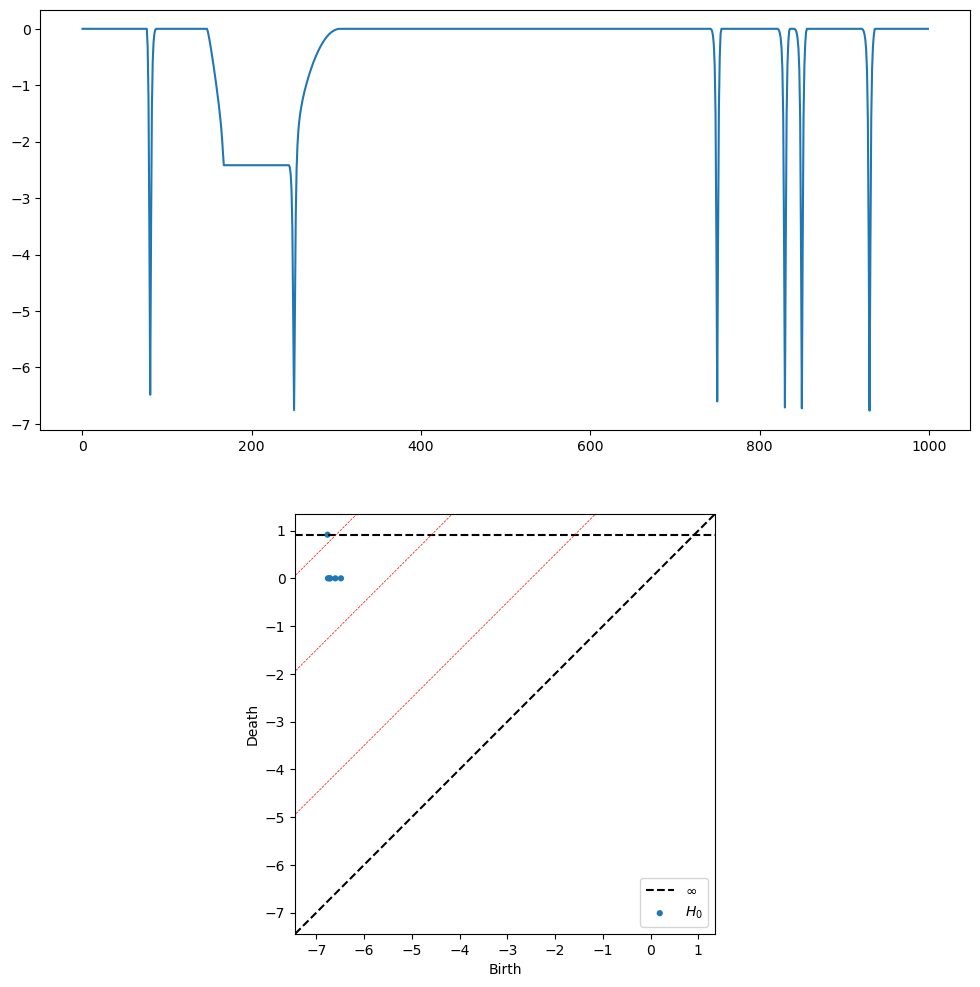

In [6]:
plt.close('all')

fig, ax = plt.subplots(2, 1, figsize = (12, 12))
ax[0].plot(arr1)

pd = cripser.computePH(arr1, maxdim=0)
pd = [pd[pd[:,0]==i,1:3] for i in range(1)]
persim.plot_diagrams(pd, ax=ax[1])

eps_list = [2.5, 5.5, 7.5, 10.5]
for eps in eps_list:
    ax[1].plot([-100,100], [-100+eps,100+eps], '--', linewidth=0.5, c="r")

In [7]:
eps_list = [2.5, 5.5, 7.5, 10.5]

arr_bands = pers_band_decompose(arr[None,:], eps_list)

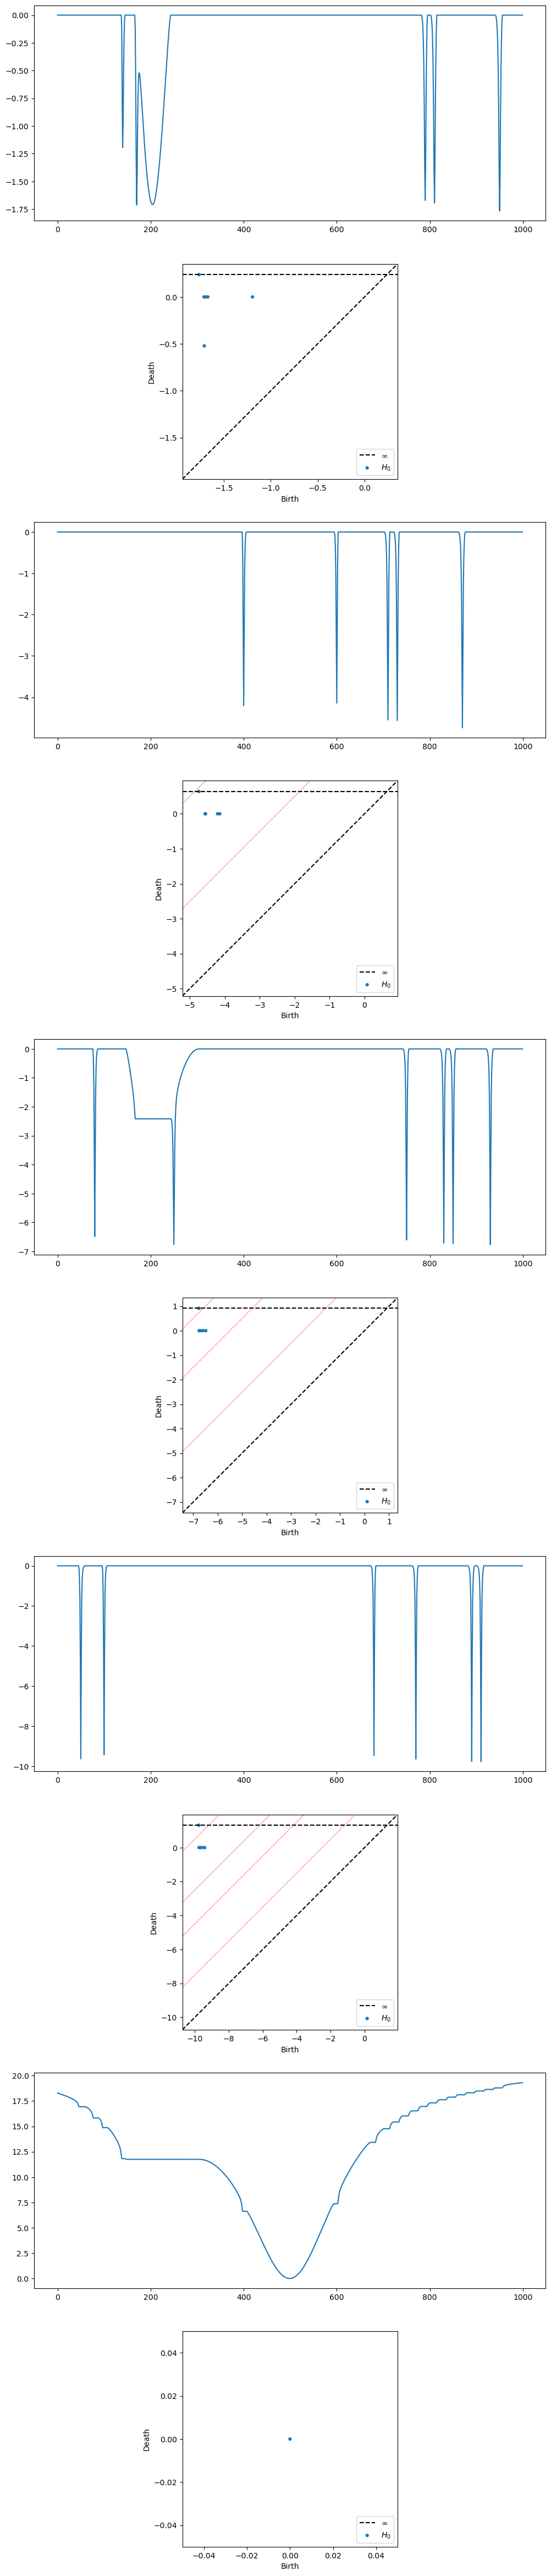

In [8]:
plt.close('all')

n = len(arr_bands)

fig, ax = plt.subplots(2*n, 1, figsize = (12, 12*n))

pd_arr_bands = []
for i in range(n):
    arr_bnd = arr_bands[i][0]
    ax[2*i].plot(x, arr_bnd)
    pd = cripser.computePH(arr_bnd, maxdim=0)
    pd_arr_bands.append(pd)
    pd = [pd[pd[:,0]==i,1:3] for i in range(1)]
    persim.plot_diagrams(pd, ax=ax[2*i + 1])

    for eps in eps_list:
        ax[2*i + 1].plot([-100,100], [-100+eps,100+eps], '--', linewidth=0.5, c="r")

In [9]:
arr_reconstructed = arr_bands[0][0].copy()
for i in range(1, len(arr_bands)):
    arr_reconstructed += arr_bands[i][0]

In [10]:
# Checking if the decomposition in fact sums up to the orignal array
np.all(arr == arr_reconstructed)

True

### Band-pass filter

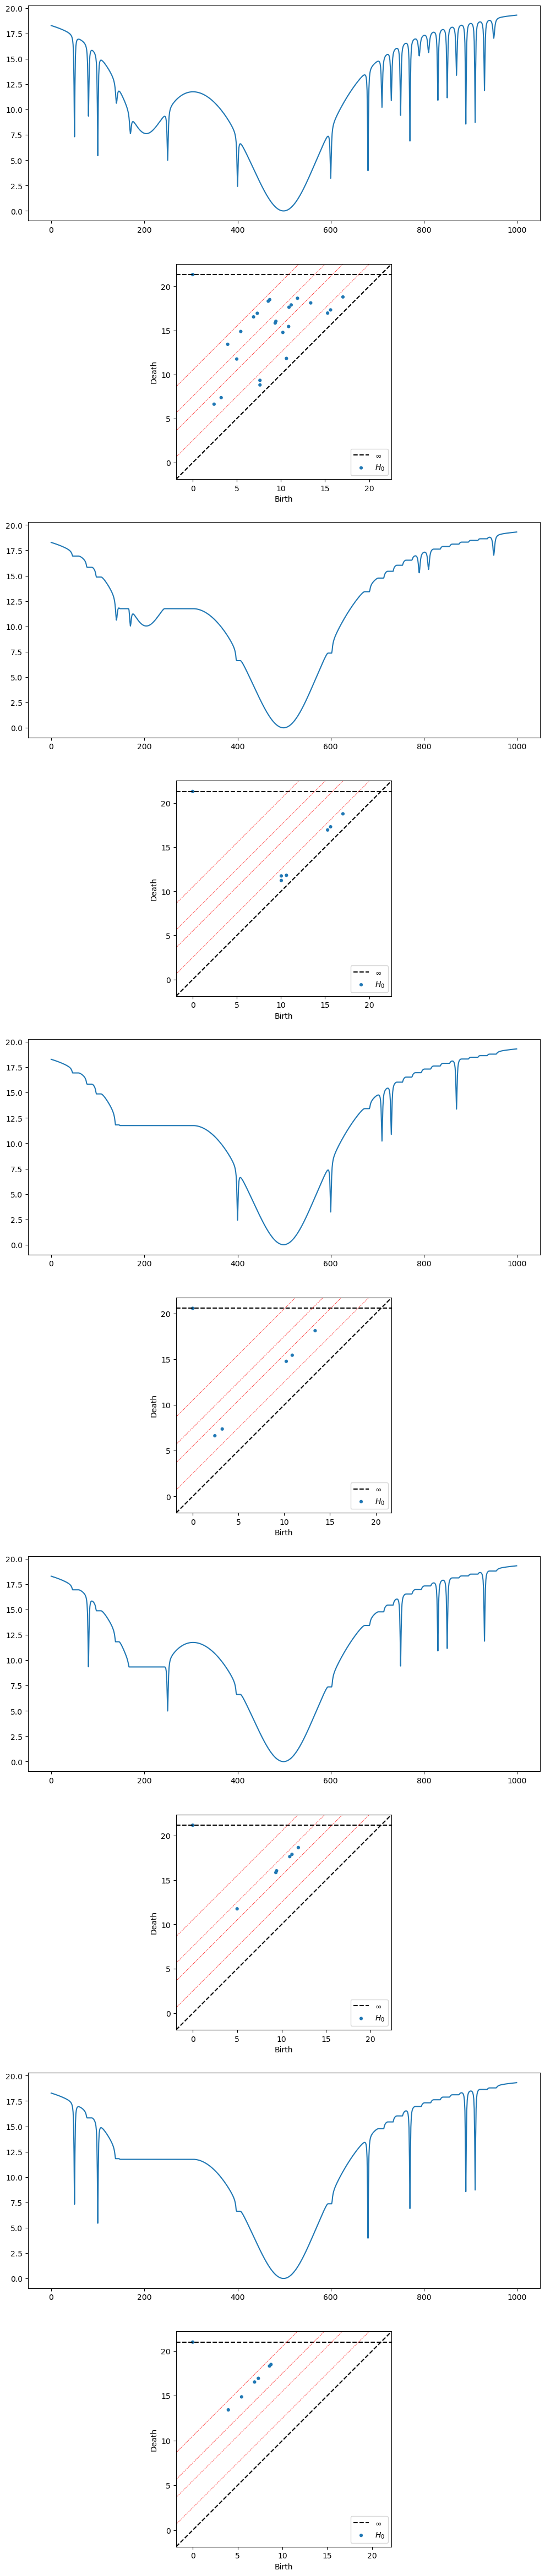

In [11]:
plt.close('all')

n = len(arr_bands)


fig, ax = plt.subplots(2*n, 1, figsize = (12, 12*n))

ax[0].plot(x, arr)
pd = cripser.computePH(arr, maxdim=0)
pd_arr = pd.copy()
pd = [pd[pd[:,0]==i,1:3] for i in range(1)]
persim.plot_diagrams(pd, ax=ax[1])
for eps in eps_list:
    ax[1].plot([-100,100], [-100+eps,100+eps], '--', linewidth=0.5, c="r")

pd_arr_bands = []
for i in range(1,n):
    arr_bnd = arr_bands[i-1][0] + arr_bands[-1][0]
    ax[2*i].plot(x, arr_bnd)
    pd = cripser.computePH(arr_bnd, maxdim=0)
    pd_arr_bands.append(pd)
    pd = [pd[pd[:,0]==i,1:3] for i in range(1)]
    persim.plot_diagrams(pd, ax=ax[2*i + 1])

    for eps in eps_list:
        ax[2*i + 1].plot([-100,100], [-100+eps,100+eps], '--', linewidth=0.5, c="r")

In [12]:
# location: [birth, death] divided by dictionaries for each band
if eps_list[0] != 0:
    eps_list = [0] + eps_list
pd_arr_dicts = [{pd_arr[i,3]: [pd_arr[i,1], pd_arr[i,2]] for i in range(pd_arr.shape[0]) if eps_list[j-1] < pd_arr[i,2] - pd_arr[i,1] < eps_list[j]} for j in range(1, len(eps_list))]
# pd_arr = pd_arr[pd_arr[:, -1].argsort()] # sort array by persistence (last entry)

In [13]:
pd_arr_bands_dicts = [{pd_arr_bands[j][i,3]: [pd_arr_bands[j][i,1], pd_arr_bands[j][i,2]] for i in range(pd_arr_bands[j].shape[0]-1)} for j in range(len(pd_arr_bands))]

In [14]:
for i in range(len(pd_arr_dicts)):
    for key in pd_arr_dicts[i].keys():
        a = pd_arr_dicts[i][key][0]
        b = pd_arr_dicts[i][key][1]
        c = pd_arr_bands_dicts[i][key][0]
        d = pd_arr_bands_dicts[i][key][1]
        if b - a != d - c:
            print(f'Different persistence for key {key}.\n Original:{b-a}\n Band:{d-c}')
        if a!=c or b!=d:
            print(f'Dislocated interval at {key}: [{a},{b}] --> [{c}, {d}]')

Dislocated interval at 204.0: [7.622422168305885,8.809220455763619] --> [10.039826557779541, 11.226624845237275]
Dislocated interval at 170.0: [7.619472646998101,9.33075455414736] --> [10.036877036471758, 11.748158943621016]


The result above shows that the persistence of each interval was preserved, at most some intervals were dislocated.

### Band filter out


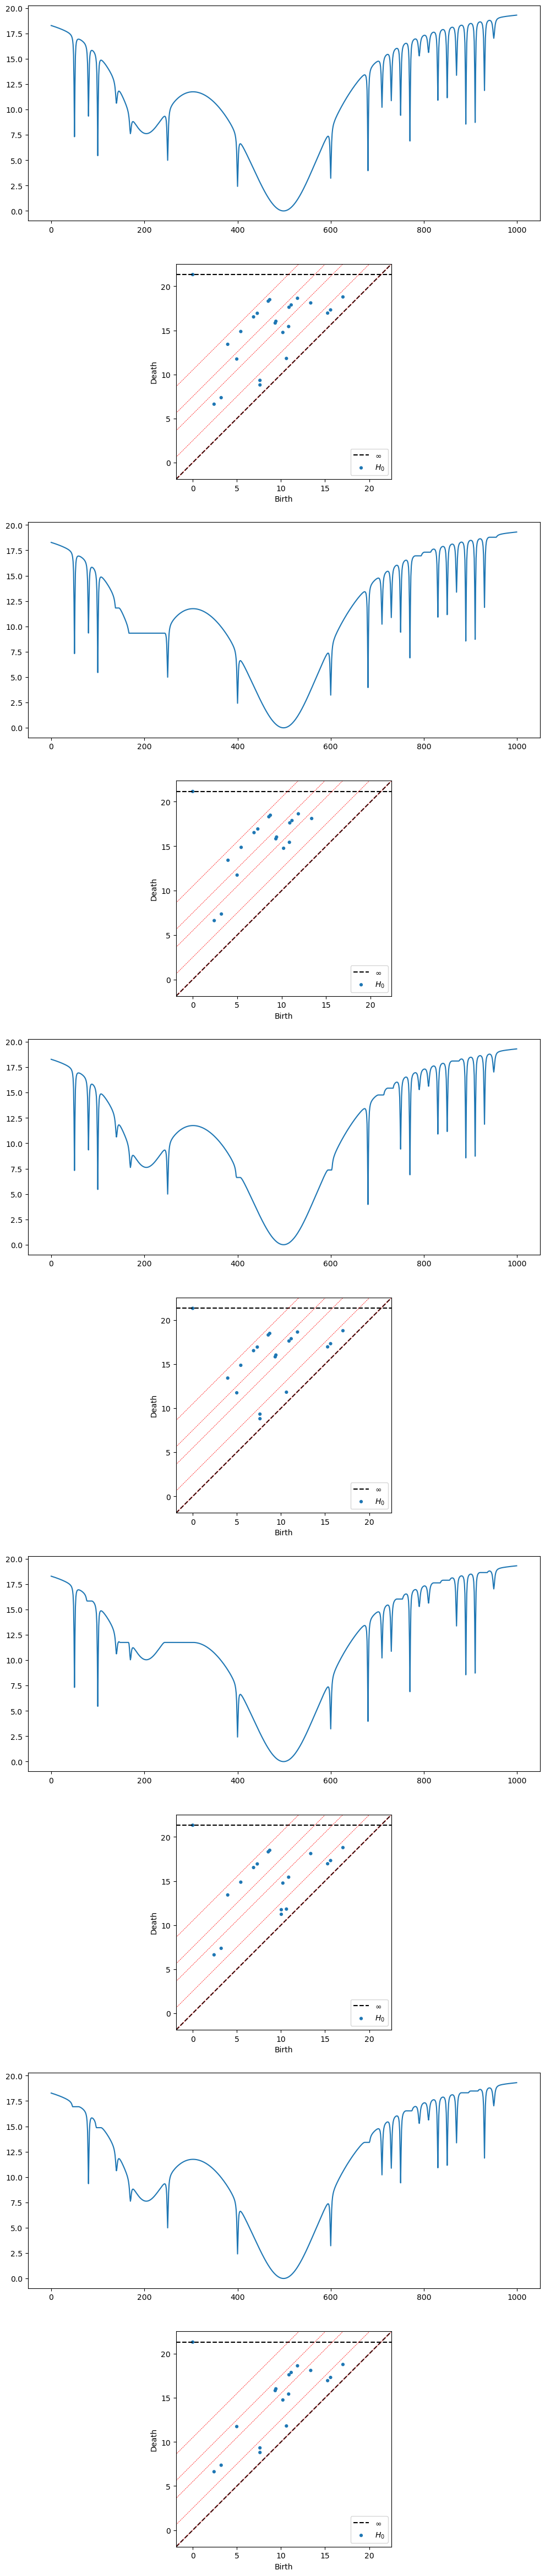

In [15]:
plt.close('all')

n = len(arr_bands)


fig, ax = plt.subplots(2*n, 1, figsize = (12, 12*n))

ax[0].plot(x, arr)
pd = cripser.computePH(arr, maxdim=0)
pd_arr = pd.copy()
pd = [pd[pd[:,0]==i,1:3] for i in range(1)]
persim.plot_diagrams(pd, ax=ax[1])
for eps in eps_list:
    ax[1].plot([-100,100], [-100+eps,100+eps], '--', linewidth=0.5, c="r")

pd_arr_bands = []
for i in range(1,n):
    arr_bnd = - arr_bands[i-1][0] + arr
    ax[2*i].plot(x, arr_bnd)
    pd = cripser.computePH(arr_bnd, maxdim=0)
    pd_arr_bands.append(pd)
    pd = [pd[pd[:,0]==i,1:3] for i in range(1)]
    persim.plot_diagrams(pd, ax=ax[2*i + 1])

    for eps in eps_list:
        ax[2*i + 1].plot([-100,100], [-100+eps,100+eps], '--', linewidth=0.5, c="r")

# torch topological

## sparsity

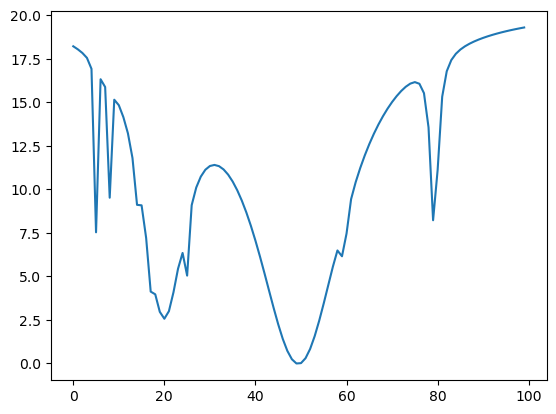

In [12]:
shek = [(500, 20, 300),
        (200, 15, 50),
        (600, 5, 5e-2),
        (250, 5, 5e-2),
        (170, 2, 5e-2),
        (140, 2, 5e-2),
        (50, 10, 5e-2),
        (80, 7, 5e-2),
        (800,10,1)
    ]

x,X = shekel(shek,resolution=100)
#X=np.zeros_like(arr)
#X = X + np.random.normal(scale=5, size=X.shape)

plt.plot(X)

In [52]:
# optimisation

n_iterations = 5000
lambda_apx = 0.2
lambda_spa = 0.1
dim = 0
tol = 1e-15
tol_count = 2000

#x,X = shekel(shek,resolution=100)
X = [1,0,0,1.1,0]

cpx = CubicalComplex(dim=1)

X = torch.as_tensor(X, dtype=torch.float, device=device)

# target function in terms of L1 norm
X_target = torch.clone(X)

## the image to be optimised
X = torch.nn.Parameter(X, requires_grad=True).to(device)

pi_null = torch.tensor([]).to(device)

## choose lr carefully!
#opt = optim.SGD([X], lr=0.05)
opt = optim.Adam([X], lr=3e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min')

## optimisation iteration
progress = tqdm(range(n_iterations))
prev_loss = np.inf
count = 0
Xs = []
for i in progress:
  # compute PD of X
    pi_source = cpx(-X)[dim].diagram
    
    # PH sparsity
    l1 = pers_loss(pi_source, pi_null,pow=1,remove_longest_D1=False,remove_longest_D2=False)
    l2 = pers_loss(pi_source, pi_null,pow=2,remove_longest_D1=False,remove_longest_D2=False).sqrt()
    loss_PH = l1/(l2+1e-30)

    # sparsity
    loss_spa = X.abs().sum()/(X**2).sum().sqrt()

    # stay close to X_target
    #loss_apx = torch.nn.functional.l1_loss(X, X_target)
    loss_apx = (X.sum() - 2)**2 + X.abs().sum()
    #loss_apx = (X-X_target).abs().max()
    
    # gradient descent
    loss = loss_PH + lambda_spa * loss_spa + lambda_apx * loss_apx
    opt.zero_grad()
    loss.backward()
    opt.step()
    scheduler.step(loss)
    progress.set_postfix(loss=f'PH: {loss_PH.item():.08f},sparsity: {loss_spa.item():.08f},approx: {loss_apx.item():.08f}')
    if (prev_loss-loss)<tol:
      count += 1
      if count > tol_count:
        break
    else:
      prev_loss = loss.item()
      count = 0
    if i%20 == 0:
      Xs.append(X.detach().cpu().numpy().copy())
## get results
X = X.detach().cpu().numpy()
#Y = Y.detach().numpy()
print(pi_source,l1,l2)

100%|██████████| 5000/5000 [00:07<00:00, 711.92it/s, loss=PH: 1.00000000,sparsity: 1.00455296,approx: 1.75110221]


tensor([[-1.4601e+00, -1.0564e-04]], grad_fn=<StackBackward0>) tensor(1.4600, grad_fn=<SumBackward0>) tensor(1.4600, grad_fn=<SqrtBackward0>)


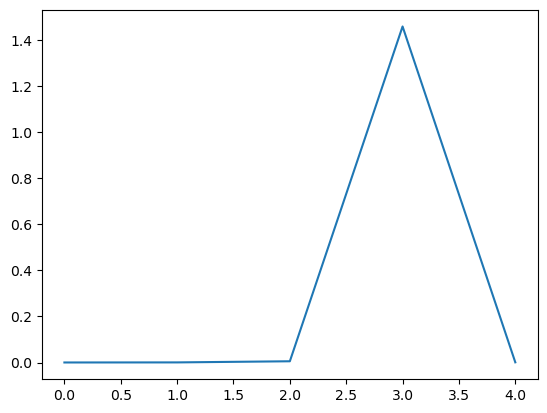

In [53]:
plt.plot(X)

## top-NMF

In [81]:
lr = 0.003 # learning rate for gradient descent
target_sparsity = 0.7 # set to None, if you are not using

gd_iter = 1 # gradient descent update per iteration
mu_iter = 1 # multiplicative update per iteration
W_iter = 1 # W update per multiplicative update iteration

lambda_apx = 0. # (we do not have to use for mu) reconstruction loss in gradient descent
lambda_spa = 0. # (we do not have to use for mu)

# top-NMF
lambda_top = 0.1

##
n_components = 20 # number of basis vectors
n_iterations = 2000
PH_dims = [0] # which dim to look at in PH
tol = 1e-4 # early stopping
tol_count = 200 # early stopping

loss_fn = torch.nn.MSELoss() # approximation error


## dagtaset of shape (n_samples, n_features)
#X = np.array([ [1,0,0,1,1] ]) # 1d
#X = np.array([ [[1,0,0],[1,0,1],[0,0,1]] ]) # 2d
X = faces.reshape((n_samples,*image_shape)) # face dataset

### Start
n_samples = X.shape[0]
data_dims = X.shape[1:]
n_features = X[0].size

# Initialize with random nonnegative values
W = np.abs(np.random.normal(size=(n_samples, n_components)))
V = np.abs(np.random.normal(size=(n_components, n_features)))


X = torch.as_tensor(X.reshape(n_samples,-1), dtype=torch.float, device=device)
W = torch.tensor(W, dtype=torch.float, device=device, requires_grad=True)
V = torch.tensor(V, dtype=torch.float, device=device, requires_grad=True)

print(X.shape,W.shape,V.shape)

opt = optim.AdamW([W, V], lr=lr) # Adam, AdamW, or NAdam?
scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min')


cpx = CubicalComplex(superlevel=True,dim=len(data_dims))
pi_null = torch.tensor([]).to(device)

## optimisation iteration
progress = tqdm(range(n_iterations))
prev_loss = np.inf
count = 0
epsilon = 1e-10
ts = np.sqrt(V.shape[1]) - target_sparsity * (np.sqrt(V.shape[1]) - 1)
for i in progress:
    # multiplicative update
    with torch.no_grad():
        for _ in range(mu_iter):
            #update V
            if target_sparsity is None:
                W_TX = W.T @ X
                W_TWV = W.T @ W @ V + epsilon
                V *= W_TX / W_TWV
            else:
                update_W(X.T, V.T, W.T, ts) # update V with target sparsity

            #update W
            for _ in range(W_iter):
                XV_T = X @ V.T
                WVV_T = W @ V @ V.T + epsilon
                W *= XV_T / WVV_T

    # gradient descent update
    for _ in range(gd_iter):
        # compute PD of negative of W
        loss_PH=torch.tensor(0.)-n_components
        loss_spa=torch.tensor(0.)
        for j in range(n_components):
            v=V[j]
            if lambda_top>0:
                for dim in PH_dims:
                    pi_source = cpx(v.reshape(data_dims))[dim].diagram
                        
                    # PH sparsity
                    l1 = pers_loss(pi_source, pi_null,pow=1,remove_longest_D1=False,remove_longest_D2=False)
                    l2 = pers_loss(pi_source, pi_null,pow=2,remove_longest_D1=False,remove_longest_D2=False).sqrt()
                    loss_PH += l1/(l2+epsilon)
    
            # sparsity
            loss_spa += (sparsity_score(v)-target_sparsity)**2
    
        # reconstruction
        #loss_apx = torch.nn.functional.l1_loss(X, X_target)
        loss_apx = loss_fn(torch.mm(W, V),X)
    
        # gradient descent
        loss = lambda_top * loss_PH + lambda_spa * loss_spa +  lambda_apx * loss_apx
        opt.zero_grad()
        loss.backward()
        opt.step()
        scheduler.step(loss)

    # Enforce nonnegativity by clamping
    with torch.no_grad():
        W.clamp_(min=0)
        V.clamp_(min=0)
        # projection to target sparsity
        # if target_sparsity is not None:
        #     for j in range(n_components):
        #         V[j,:] = torch.as_tensor(project_to_target_sparsity(V[j].ravel(), target_sparsity))

    # display
    progress.set_postfix(loss=f'PH: {loss_PH.item():.08f},sparsity: {loss_spa.item():.08f},approx: {loss_apx.item():.08f}')
    current = lambda_top * loss_PH + lambda_spa * loss_spa + loss_apx
    if (prev_loss-current)<tol:
      count += 1
      if count > tol_count:
        break
    else:
      prev_loss = current.item()
      count = 0

## get results
X = X.detach().cpu().numpy()
W = W.detach().cpu().numpy()
V = V.detach().cpu().numpy()

torch.Size([400, 4096]) torch.Size([400, 20]) torch.Size([20, 4096])


 78%|███████▊  | 1568/2000 [06:28<01:47,  4.03it/s, loss=PH: 36.21826553,sparsity: 0.00000000,approx: 0.00609204]


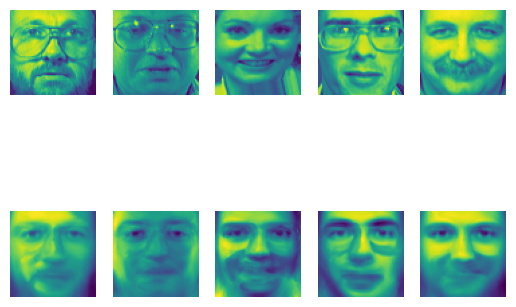

In [82]:
num = 5
fig,axs = plt.subplots(2,num)
for i in range(num):
    if len(data_dims)==1:
        sns.barplot(X[i],ax=axs[0,i])
        sns.barplot( (W@V)[i],ax=axs[1,i])
    else:
        axs[0,i].imshow(X[i].reshape(data_dims))
        axs[1,i].imshow((W@V)[i].reshape(data_dims))
        axs[0,i].axis("off")
        axs[1,i].axis("off")

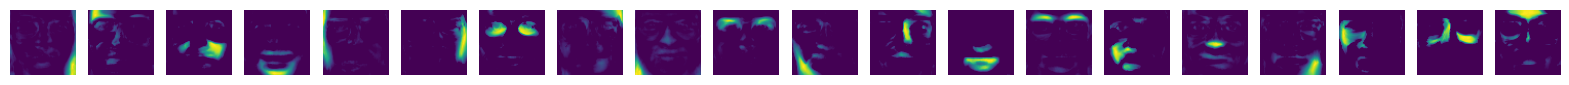

In [83]:
fig,axs = plt.subplots(1,len(V),figsize=(20,10))
for i,v in enumerate(V):
    #print(i,cpx(torch.tensor(v).reshape(data_dims))[PH_dims[0]].diagram)
    if len(data_dims)==1:
        sns.barplot(v,ax=axs[i])
    else:
        axs[i].imshow(v.reshape(data_dims))
        axs[i].axis("off")
    #axs[i].set_title(v)

In [157]:
U=torch.tensor(W[0]).reshape(data_dims)
cpx(U),U


([PersistenceInformation(pairing=tensor([[1, 2, 0, 1]]), diagram=tensor([[-1,  0]]), dimension=0),
  PersistenceInformation(pairing=tensor([], size=(0, 4), dtype=torch.int64), diagram=tensor([], size=(0, 2), dtype=torch.int64), dimension=1)],
 tensor([[1, 0, 0],
         [1, 0, 1]]))

### face

In [7]:
from sklearn.datasets import fetch_olivetti_faces
faces, _ = fetch_olivetti_faces(return_X_y=True, shuffle=True)
n_samples, n_features = faces.shape
n_row, n_col = 2, 3
image_shape = (64, 64)
print(faces.shape)
X = faces.reshape((n_samples,*image_shape)) # face dataset

def plot_gallery(images, title="", n_col=n_col, n_row=n_row, cmap=plt.cm.gray):
    plt.figure(figsize=(2. * n_col, 2.26 * n_row))
    plt.suptitle(title, size=16)
    for i, comp in enumerate(images[:(n_col*n_row)]):
        plt.subplot(n_row, n_col, i + 1)
        vmax = max(comp.max(), -comp.min())
        plt.imshow(comp.reshape(image_shape), cmap=cmap,
                   interpolation='nearest',
                   vmin=-vmax, vmax=vmax)
        plt.xticks(())
        plt.yticks(())
    plt.subplots_adjust(0.01, 0.05, 0.99, 0.93, 0.04, 0.)


(400, 4096)


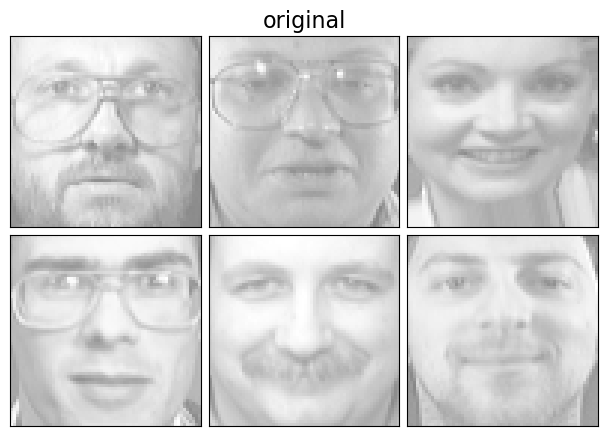

In [8]:
plot_gallery(faces,title="original")

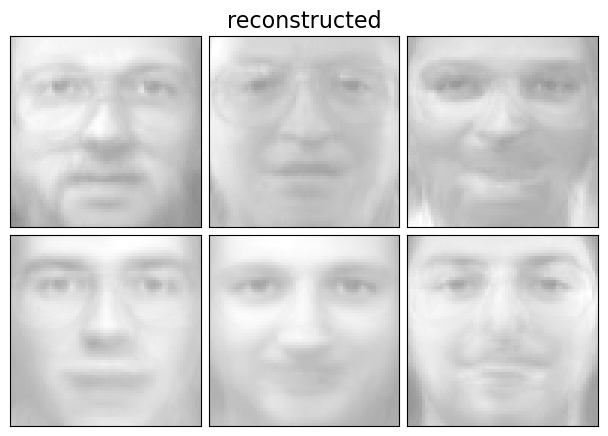

In [11]:
from sklearn import decomposition

n_components = 50 # number of basis vectors

model = decomposition.NMF(n_components=n_components, init='nndsvdar',solver='mu',alpha_W=0.001, alpha_H='same', l1_ratio=0.3)
model.fit(faces)
V=model.components_
result = model.inverse_transform(model.transform(faces))

plot_gallery(result,title="reconstructed")

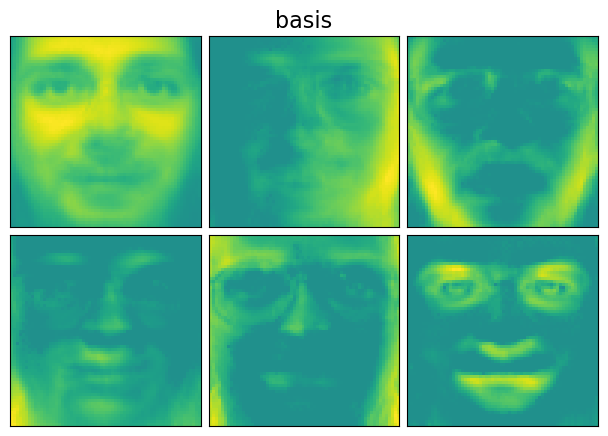

In [12]:
plot_gallery(V,title="basis",cmap="viridis")

In [13]:
V.sum(axis=1)

array([2057.1736  ,  776.85376 ,  648.0902  ,  520.1851  ,  463.3924  ,
        419.20572 ,  419.7652  ,  391.75232 ,  284.16162 ,  317.1739  ,
        325.63058 ,  279.47064 ,  250.51671 ,  271.27567 ,  270.02612 ,
        277.30484 ,  249.44449 ,  248.33179 ,  244.13466 ,  213.92393 ,
        187.15633 ,  181.05309 ,  241.12526 ,  166.46545 ,  175.66695 ,
        174.81467 ,  170.91336 ,  151.01898 ,  157.43895 ,  165.83562 ,
        162.39813 ,  117.66553 ,  187.21272 ,  106.602905,   84.02441 ,
        159.82135 ,  144.19753 ,  141.8953  ,   89.86745 ,   53.99762 ,
        105.98367 ,   61.569088,   82.1092  ,    0.      ,   56.358192,
         49.26151 ,  145.78046 ,  211.69696 ,   76.70538 ,    0.      ],
      dtype=float32)

  0%|          | 0/2000 [00:00<?, ?it/s]

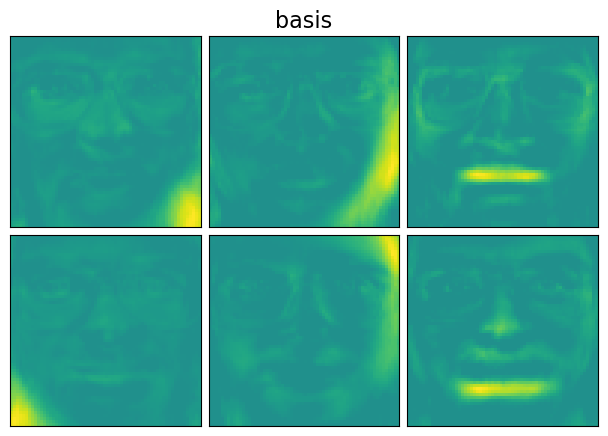

In [30]:
import importlib
import sparse_nmf
importlib.reload(sparse_nmf)

r = 25
spar = 0.5
maxiter = 2000
V,W = sparse_nmf.sparse_nmf(faces.T, r, maxiter, spar)
plot_gallery(V.T,title="basis",cmap="viridis")

## filter

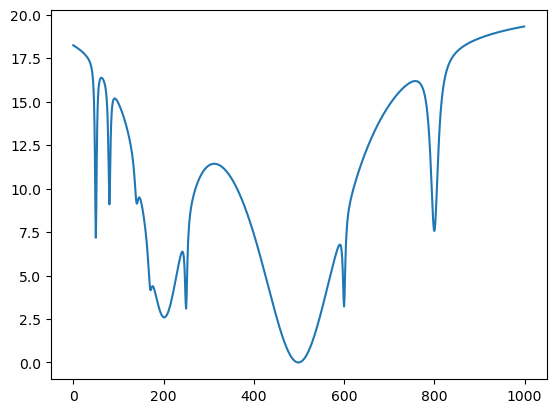

In [17]:
# initial function
shek = [(500, 20, 300),
        (200, 15, 50),
        (600, 5, 5e-2),
        (250, 5, 5e-2),
        (170, 2, 5e-2),
        (140, 2, 5e-2),
        (50, 10, 5e-2),
        (80, 7, 5e-2),
        (800,10,1)
    ]

x,X = shekel(shek,resolution=1000)
#X=np.zeros_like(arr)
#X = X + np.random.normal(scale=5, size=X.shape)

PH_X = cripser.computePH(X)
PH_X = PH_X[PH_X[:,0]==0,1:3]

plt.plot(X)

In [18]:
np.diff(PH_X)

array([[2.37789976e-001],
       [3.27692037e+000],
       [3.55259597e+000],
       [3.63702953e-001],
       [8.83116990e+000],
       [6.08591822e+000],
       [8.62046195e+000],
       [9.19550495e+000],
       [1.79769313e+308]])

In [19]:
# optimisation

n_iterations = 3500
lambda_close = 0
dim = 0
tol = 1e-15
tol_count = 200
backend = "torch_topological"
#backend = "gudhi"

loss_fn = pers_loss

if backend == "torch_topological":
  cpx = CubicalComplex(dim=2)

X = torch.as_tensor(X, dtype=torch.float, device=device)

# target function in terms of L1 norm
X_target = torch.clone(X)

## the image to be optimised
X = torch.nn.Parameter(X, requires_grad=True).to(device)

## target PH
#pi_target = cpx(Y)[dim].diagram
#pi_target = torch.tensor([[0,5],[0,2]])
pi_target = torch.tensor(band_PH(PH_X,4,1000)).to(device)
print(pi_target)

## choose lr carefully!
#opt = optim.SGD([X], lr=0.05)
opt = optim.Adam([X], lr=3e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min')

## optimisation iteration (optimising X targeting Y)
progress = tqdm(range(n_iterations))
prev_loss = np.inf
count = 0
Xs = []
for i in progress:
  # compute PD of X
    if backend == "gudhi":
      st = gd.CubicalComplex(vertices = X) # currently, GUDHI does not support torch...
      st.compute_persistence()
      pi_source = st.persistence_intervals_in_dimension(0)
    elif backend == "torch_topological":
      pi_source = cpx(X)[dim].diagram
    else:
      print("wrong backend!")
    # comparing persistence
    loss_PH = loss_fn(pi_source, pi_target)
    # stay close to X_target
    #loss_func = torch.nn.functional.l1_loss(X, X_target)
    loss_func = (X-X_target).abs().max()
    # gradient descent
    loss = loss_PH + lambda_close * loss_func
    opt.zero_grad()
    loss.backward()
    opt.step()
    scheduler.step(loss)
    progress.set_postfix(loss=f'PH: {loss_PH.item():.08f},func: {loss_func.item():.08f}')
    if (prev_loss-loss)<tol:
      count += 1
      if count > tol_count:
        break
    else:
      prev_loss = loss.item()
      count = 0
    if i%20 == 0:
      Xs.append(X.detach().cpu().numpy().copy())
## get results
X = X.detach().cpu().numpy()
#Y = Y.detach().numpy()

tensor([[ 2.5930, 11.4242],
        [ 9.0900, 15.1759],
        [ 7.5594, 16.1798],
        [ 7.1732, 16.3687]], dtype=torch.float64)


 55%|█████▌    | 1940/3500 [00:05<00:04, 359.38it/s, loss=PH: 0.00000000,func: 2.26892757]


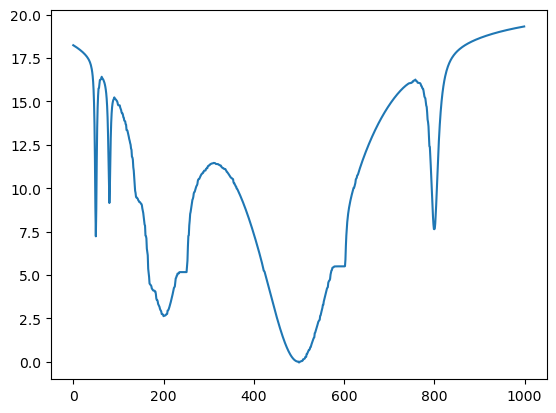

In [20]:
plt.plot(X)

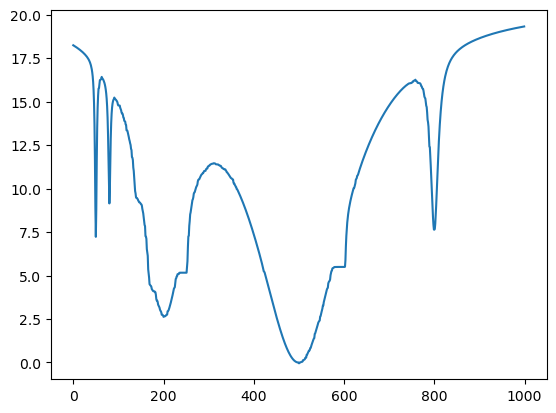

In [21]:
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots()

x = np.arange(len(X))
line, = ax.plot(Xs[0])

def animate(i):
    line.set_ydata(Xs[i])  # update the data.
    return line,

ani = animation.FuncAnimation(
    fig, animate, interval=20, blit=True, frames=len(Xs))

HTML(ani.to_jshtml())

#plt.show()

In [22]:
final_PH=cpx(torch.tensor(X))
final_PH[dim].diagram

tensor([[ 5.1609,  5.1609],
        [ 5.4926,  5.4926],
        [ 5.4926,  5.4926],
        [ 2.6223, 11.4535],
        [ 9.1431, 15.2291],
        [ 7.6348, 16.2553],
        [ 7.2226, 16.4181],
        [-0.0472, 19.3158]])

In [23]:
st = gd.CubicalComplex(vertices = X)
st.compute_persistence()
st.persistence_intervals_in_dimension(0)


array([[ 5.16087532,  5.16089582],
       [ 5.49258518,  5.49258614],
       [ 5.49255419,  5.49258614],
       [ 2.62231922, 11.4534893 ],
       [ 9.14314747, 15.2290659 ],
       [ 7.63482332, 16.25528526],
       [ 7.2226305 , 16.41813469],
       [-0.04715257,         inf]])

In [24]:
with np.printoptions(formatter={'float': '{:.8f}'.format}):
  PH_X = cripser.computePH(X)
  print(PH_X[PH_X[:,0]==0,1:3])

[[5.16087532 5.16089582]
 [5.49258518 5.49258614]
 [5.49255419 5.49258614]
 [2.62231922 11.45348930]
 [9.14314747 15.22906590]
 [7.63482332 16.25528526]
 [7.22263050 16.41813469]
 [-0.04715257
  179769313486231570814527423731704356798070567525844996598917476803157260780028538760589558632766878171540458953514382464234321326889464182768467546703537516986049910576551282076245490090389328944075868508455133942304583236903222948165808559332123348274797826204144723168738177180919299881250404026184124858368.00000000]]


## 2D

In [25]:
####

## synthetic image
n,m = 30,30
#X = np.random.uniform(0,1,(n,m))
y, x = np.mgrid[-6:6:n*1j, -3:3:m*1j]
noise = 0.0

X = np.cos(2*x) - np.sin(2*y) + 0.1*x

X = X + np.random.normal(scale=noise, size=X.shape)

# function with target PH
Y = np.cos(x) - np.sin(y) + 0.1*y
#Y = 0.1*(x**2 + y**2)
Y = torch.as_tensor(Y, dtype=torch.float, device=device)


TypeError: Invalid shape (1000,) for image data

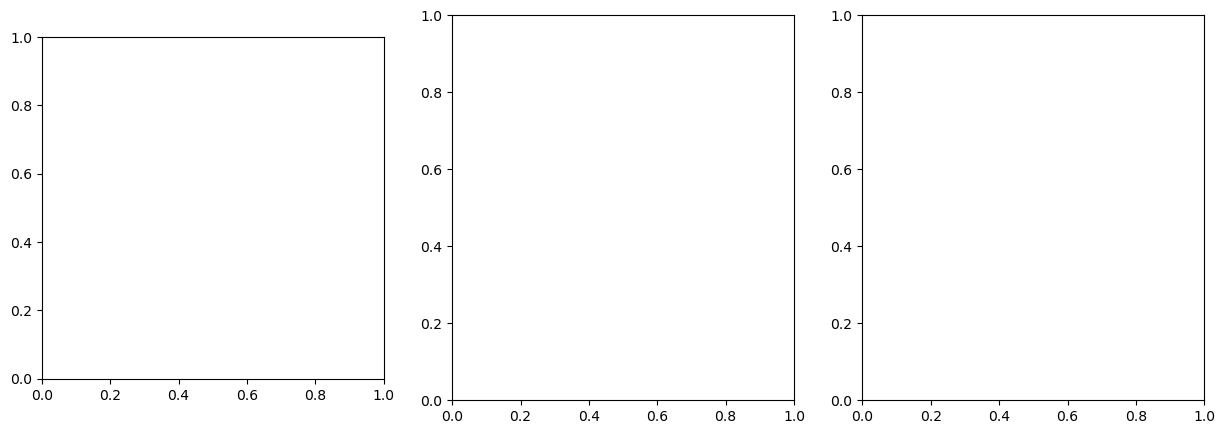

In [26]:
# plot
fig, axs = plt.subplots(1,3,figsize=(15,5))
axs[0].imshow(X_target)
axs[0].set_title("initial")
axs[1].imshow(X)
axs[1].set_title("optimised")
axs[2].imshow(Y)
axs[2].set_title("target")


In [ ]:
import persim
import cripser
fig, axs = plt.subplots(1,3,figsize=(15,5))
PH_X0 = cripser.computePH(X_target)
PH_X0 = [PH_X0[PH_X0[:,0]==i,1:3] for i in range(2)]
persim.plot_diagrams(PH_X0,labels=["initial H0","initial H1"],ax=axs[0])
PH_X = cripser.computePH(X)
PH_X = [PH_X[PH_X[:,0]==i,1:3] for i in range(2)]
persim.plot_diagrams(PH_X,labels=["opt H0", "opt H1"],ax=axs[1])
PH_Y = cripser.computePH(Y)
PH_Y = [PH_Y[PH_Y[:,0]==i,1:3] for i in range(2)]
persim.plot_diagrams(PH_Y,labels=["target H0","target H1"],ax=axs[2])

In [ ]:
(PH_X0[0])

# GUDHI